In [1]:
!git clone https://github.com/michaelhunter12/linear_models.git

Cloning into 'linear_models'...
remote: Enumerating objects: 92, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 92 (delta 26), reused 12 (delta 12), pack-reused 55 (from 3)
Receiving objects: 100% (92/92), 5.16 MiB | 10.50 MiB/s, done.
Resolving deltas: 100% (27/27), done.


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
houses = pd.read_csv('linear_models/lab/data/pierce_county_house_sales.csv')
houses.head()

,sale_date,sale_price,house_square_feet,attic_finished_square_feet,basement_square_feet,attached_garage_square_feet,detached_garage_square_feet,fireplaces,hvac_description,exterior,interior,stories,roof_cover,year_built,bedrooms,bathrooms,waterfront_type,view_quality,utility_sewer
0,2020-01-02,380000,2157,0,0,528,0,0,Warm and Cool Air Zone,Frame Siding,Drywall,2,Composition Shingle,1993,3,3,NaN,NaN,SEWER/SEPTIC INSTALLED
1,2020-01-02,383000,2238,0,0,396,0,0,Forced Air,Frame Siding,Drywall,2,Composition Shingle,2017,4,3,NaN,NaN,SEWER/SEPTIC INSTALLED
2,2020-01-01,419900,1452,0,0,0,0,1,Forced Air,Frame Siding,Drywall,1,Built Up Rock,1965,3,2,NaN,NaN,SEWER/SEPTIC INSTALLED
3,2020-01-02,251660,832,0,0,0,0,0,Forced Air,Frame Vinyl,Drywall,1,Composition Shingle,1919,2,1,NaN,NaN,SEWER/SEPTIC INSTALLED
4,2020-01-02,500000,1780,0,384,484,0,1,Forced Air,Frame Siding,Drywall,1,Composition Shingle,1955,3,2,NaN,NaN,SEWER/SEPTIC INSTALLED


In [4]:
houses.dtypes

,0
sale_date,object
sale_price,int64
house_square_feet,int64
attic_finished_square_feet,int64
basement_square_feet,int64
attached_garage_square_feet,int64
detached_garage_square_feet,int64
fireplaces,int64
hvac_description,object
exterior,object


In [5]:
houses['age'] = 2026 - houses['year_built']
houses.head()

,sale_date,sale_price,house_square_feet,attic_finished_square_feet,basement_square_feet,attached_garage_square_feet,detached_garage_square_feet,fireplaces,hvac_description,exterior,interior,stories,roof_cover,year_built,bedrooms,bathrooms,waterfront_type,view_quality,utility_sewer,age
0,2020-01-02,380000,2157,0,0,528,0,0,Warm and Cool Air Zone,Frame Siding,Drywall,2,Composition Shingle,1993,3,3,NaN,NaN,SEWER/SEPTIC INSTALLED,33
1,2020-01-02,383000,2238,0,0,396,0,0,Forced Air,Frame Siding,Drywall,2,Composition Shingle,2017,4,3,NaN,NaN,SEWER/SEPTIC INSTALLED,9
2,2020-01-01,419900,1452,0,0,0,0,1,Forced Air,Frame Siding,Drywall,1,Built Up Rock,1965,3,2,NaN,NaN,SEWER/SEPTIC INSTALLED,61
3,2020-01-02,251660,832,0,0,0,0,0,Forced Air,Frame Vinyl,Drywall,1,Composition Shingle,1919,2,1,NaN,NaN,SEWER/SEPTIC INSTALLED,107
4,2020-01-02,500000,1780,0,384,484,0,1,Forced Air,Frame Siding,Drywall,1,Composition Shingle,1955,3,2,NaN,NaN,SEWER/SEPTIC INSTALLED,71


In [6]:
houses.value_counts('exterior')

,count
exterior,
Frame Siding,14577
Frame Vinyl,1724
Masonry Common Brick,208
Frame Stucco,156
Masonry Concrete Block,43
Finished Cottage,41
Frame Rustic Log,21
Log,12
Frame Hardboard,11


In [7]:
houses.value_counts('hvac_description')

,count
hvac_description,
Forced Air,10382
Electric Baseboard,2668
Heat Pump,2084
Warm and Cool Air Zone,1268
Floor/Wall Furnace,174
Hot Water Baseboard,146
No Heat,82
Electric,2
Floor Wall Furnace,1


In [8]:
houses.value_counts('interior')

,count
interior,
Drywall,16777
Paneling,30


In [9]:
houses.value_counts('roof_cover')

,count
roof_cover,
Composition Shingle,15775
Concrete Tile,308
Built Up Rock,236
Formed Seam Metal,232
Wood Shake,197
Preformed Metal,58


In [10]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform the 'exterior' column
houses['exterior_encoded'] = le.fit_transform(houses['exterior'])

# Create a mapping table
exterior_mapping = pd.DataFrame({'exterior_type': le.classes_, 'encoded_value': le.transform(le.classes_)})

display(exterior_mapping)

#from GeminiAI

,exterior_type,encoded_value
0,Cedar A-Frame,0
1,Cedar Finished Cabin,1
2,Cedar Unfinished Cabin,2
3,Finished Cottage,3
4,Frame Hardboard,4
5,Frame Rustic Log,5
6,Frame Siding,6
7,Frame Stucco,7
8,Frame Vinyl,8
9,Log,9


In [11]:
le = LabelEncoder()

houses['interior_encoded'] = le.fit_transform(houses['interior'])

interior_mapping = pd.DataFrame({'interior_type': le.classes_, 'encoded_value': le.transform(le.classes_)})

display(interior_mapping)

,interior_type,encoded_value
0,Drywall,0
1,Paneling,1
2,NaN,2


In [12]:
le = LabelEncoder()

houses['hvac_description_encoded'] = le.fit_transform(houses['hvac_description'])

hvac_description_mapping = pd.DataFrame({'hvac_description_type': le.classes_, 'encoded_value': le.transform(le.classes_)})

display(hvac_description_mapping)

,hvac_description_type,encoded_value
0,Electric,0
1,Electric Baseboard,1
2,Floor Wall Furnace,2
3,Floor/Wall Furnace,3
4,Forced Air,4
5,Heat Pump,5
6,Hot Water Baseboard,6
7,No Heat,7
8,Warm and Cool Air Zone,8
9,NaN,9


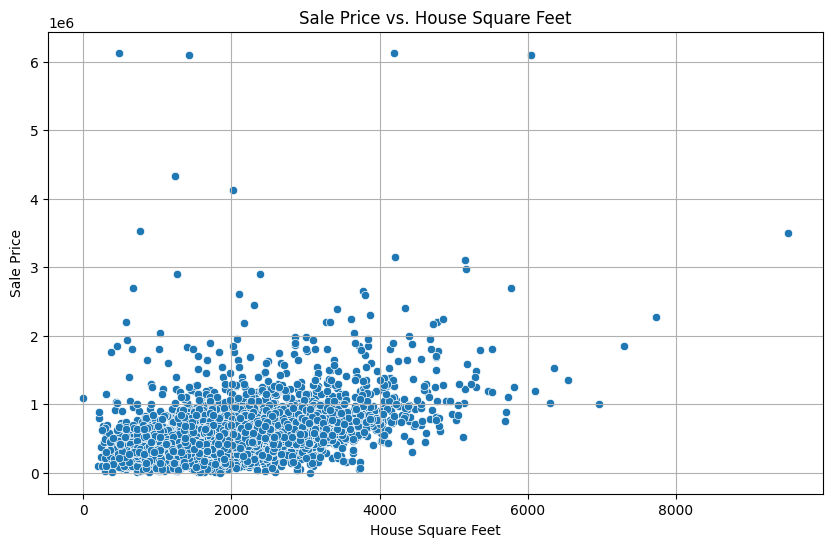

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=houses, x='house_square_feet', y='sale_price')
plt.title('Sale Price vs. House Square Feet')
plt.xlabel('House Square Feet')
plt.ylabel('Sale Price')
plt.grid(True)
plt.show()

In [16]:
houses_train, houses_test = train_test_split(houses, test_size=0.2, random_state=42)

print(f'Shape of houses_train: {houses_train.shape}')
print(f'Shape of houses_test: {houses_test.shape}')

Shape of houses_train: (13451, 23)
Shape of houses_test: (3363, 23)


### Model 1: Predict `sale_price` using `house_square_feet`

In [17]:
model_name = "Model 1: house_square_feet"

# Define features (X) and target (y)
X_train_1 = houses_train[['house_square_feet']]
y_train_1 = houses_train['sale_price']
X_test_1 = houses_test[['house_square_feet']]
y_test_1 = houses_test['sale_price']

# Initialize and fit the linear regression model
model_1 = LinearRegression()
model_1.fit(X_train_1, y_train_1)

# Make predictions
y_train_pred_1 = model_1.predict(X_train_1)
y_test_pred_1 = model_1.predict(X_test_1)

# Calculate R^2 and RMSE for training set
r2_train_1 = r2_score(y_train_1, y_train_pred_1)
rmse_train_1 = np.sqrt(mean_squared_error(y_train_1, y_train_pred_1))

# Calculate R^2 and RMSE for test set
r2_test_1 = r2_score(y_test_1, y_test_pred_1)
rmse_test_1 = np.sqrt(mean_squared_error(y_test_1, y_test_pred_1))

print(f"--- {model_name} ---")
print(f"Training R^2: {r2_train_1:.4f}")
print(f"Training RMSE: {rmse_train_1:.2f}")
print(f"Test R^2: {r2_test_1:.4f}")
print(f"Test RMSE: {rmse_test_1:.2f}")

#GeminiAI

--- Model 1: house_square_feet ---
Training R^2: 0.2814
Training RMSE: 195447.67
Test R^2: 0.2625
Test RMSE: 220635.05


### Model 2: Predict `sale_price` using `age`

In [18]:
model_name = "Model 2: age"

# Define features (X) and target (y)
X_train_2 = houses_train[['age']]
y_train_2 = houses_train['sale_price']
X_test_2 = houses_test[['age']]
y_test_2 = houses_test['sale_price']

# Initialize and fit the linear regression model
model_2 = LinearRegression()
model_2.fit(X_train_2, y_train_2)

# Make predictions
y_train_pred_2 = model_2.predict(X_train_2)
y_test_pred_2 = model_2.predict(X_test_2)

# Calculate R^2 and RMSE for training set
r2_train_2 = r2_score(y_train_2, y_train_pred_2)
rmse_train_2 = np.sqrt(mean_squared_error(y_train_2, y_train_pred_2))

# Calculate R^2 and RMSE for test set
r2_test_2 = r2_score(y_test_2, y_test_pred_2)
rmse_test_2 = np.sqrt(mean_squared_error(y_test_2, y_test_pred_2))

print(f"--- {model_name} ---")
print(f"Training R^2: {r2_train_2:.4f}")
print(f"Training RMSE: {rmse_train_2:.2f}")
print(f"Test R^2: {r2_test_2:.4f}")
print(f"Test RMSE: {rmse_test_2:.2f}")

#GeminiAI

--- Model 2: age ---
Training R^2: 0.0528
Training RMSE: 224401.76
Test R^2: 0.0509
Test RMSE: 250287.14


### Model 3: Predict `sale_price` using `bedrooms` and `bathrooms`

In [19]:
model_name = "Model 3: bedrooms and bathrooms"

# Define features (X) and target (y)
X_train_3 = houses_train[['bedrooms', 'bathrooms']]
y_train_3 = houses_train['sale_price']
X_test_3 = houses_test[['bedrooms', 'bathrooms']]
y_test_3 = houses_test['sale_price']

# Initialize and fit the linear regression model
model_3 = LinearRegression()
model_3.fit(X_train_3, y_train_3)

# Make predictions
y_train_pred_3 = model_3.predict(X_train_3)
y_test_pred_3 = model_3.predict(X_test_3)

# Calculate R^2 and RMSE for training set
r2_train_3 = r2_score(y_train_3, y_train_pred_3)
rmse_train_3 = np.sqrt(mean_squared_error(y_train_3, y_train_pred_3))

# Calculate R^2 and RMSE for test set
r2_test_3 = r2_score(y_test_3, y_test_pred_3)
rmse_test_3 = np.sqrt(mean_squared_error(y_test_3, y_test_pred_3))

print(f"--- {model_name} ---")
print(f"Training R^2: {r2_train_3:.4f}")
print(f"Training RMSE: {rmse_train_3:.2f}")
print(f"Test R^2: {r2_test_3:.4f}")
print(f"Test RMSE: {rmse_test_3:.2f}")

--- Model 3: bedrooms and bathrooms ---
Training R^2: 0.1731
Training RMSE: 209665.39
Test R^2: 0.1545
Test RMSE: 236237.76


### Step 5: Partial Correlation Plots for Numeric Variables

/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


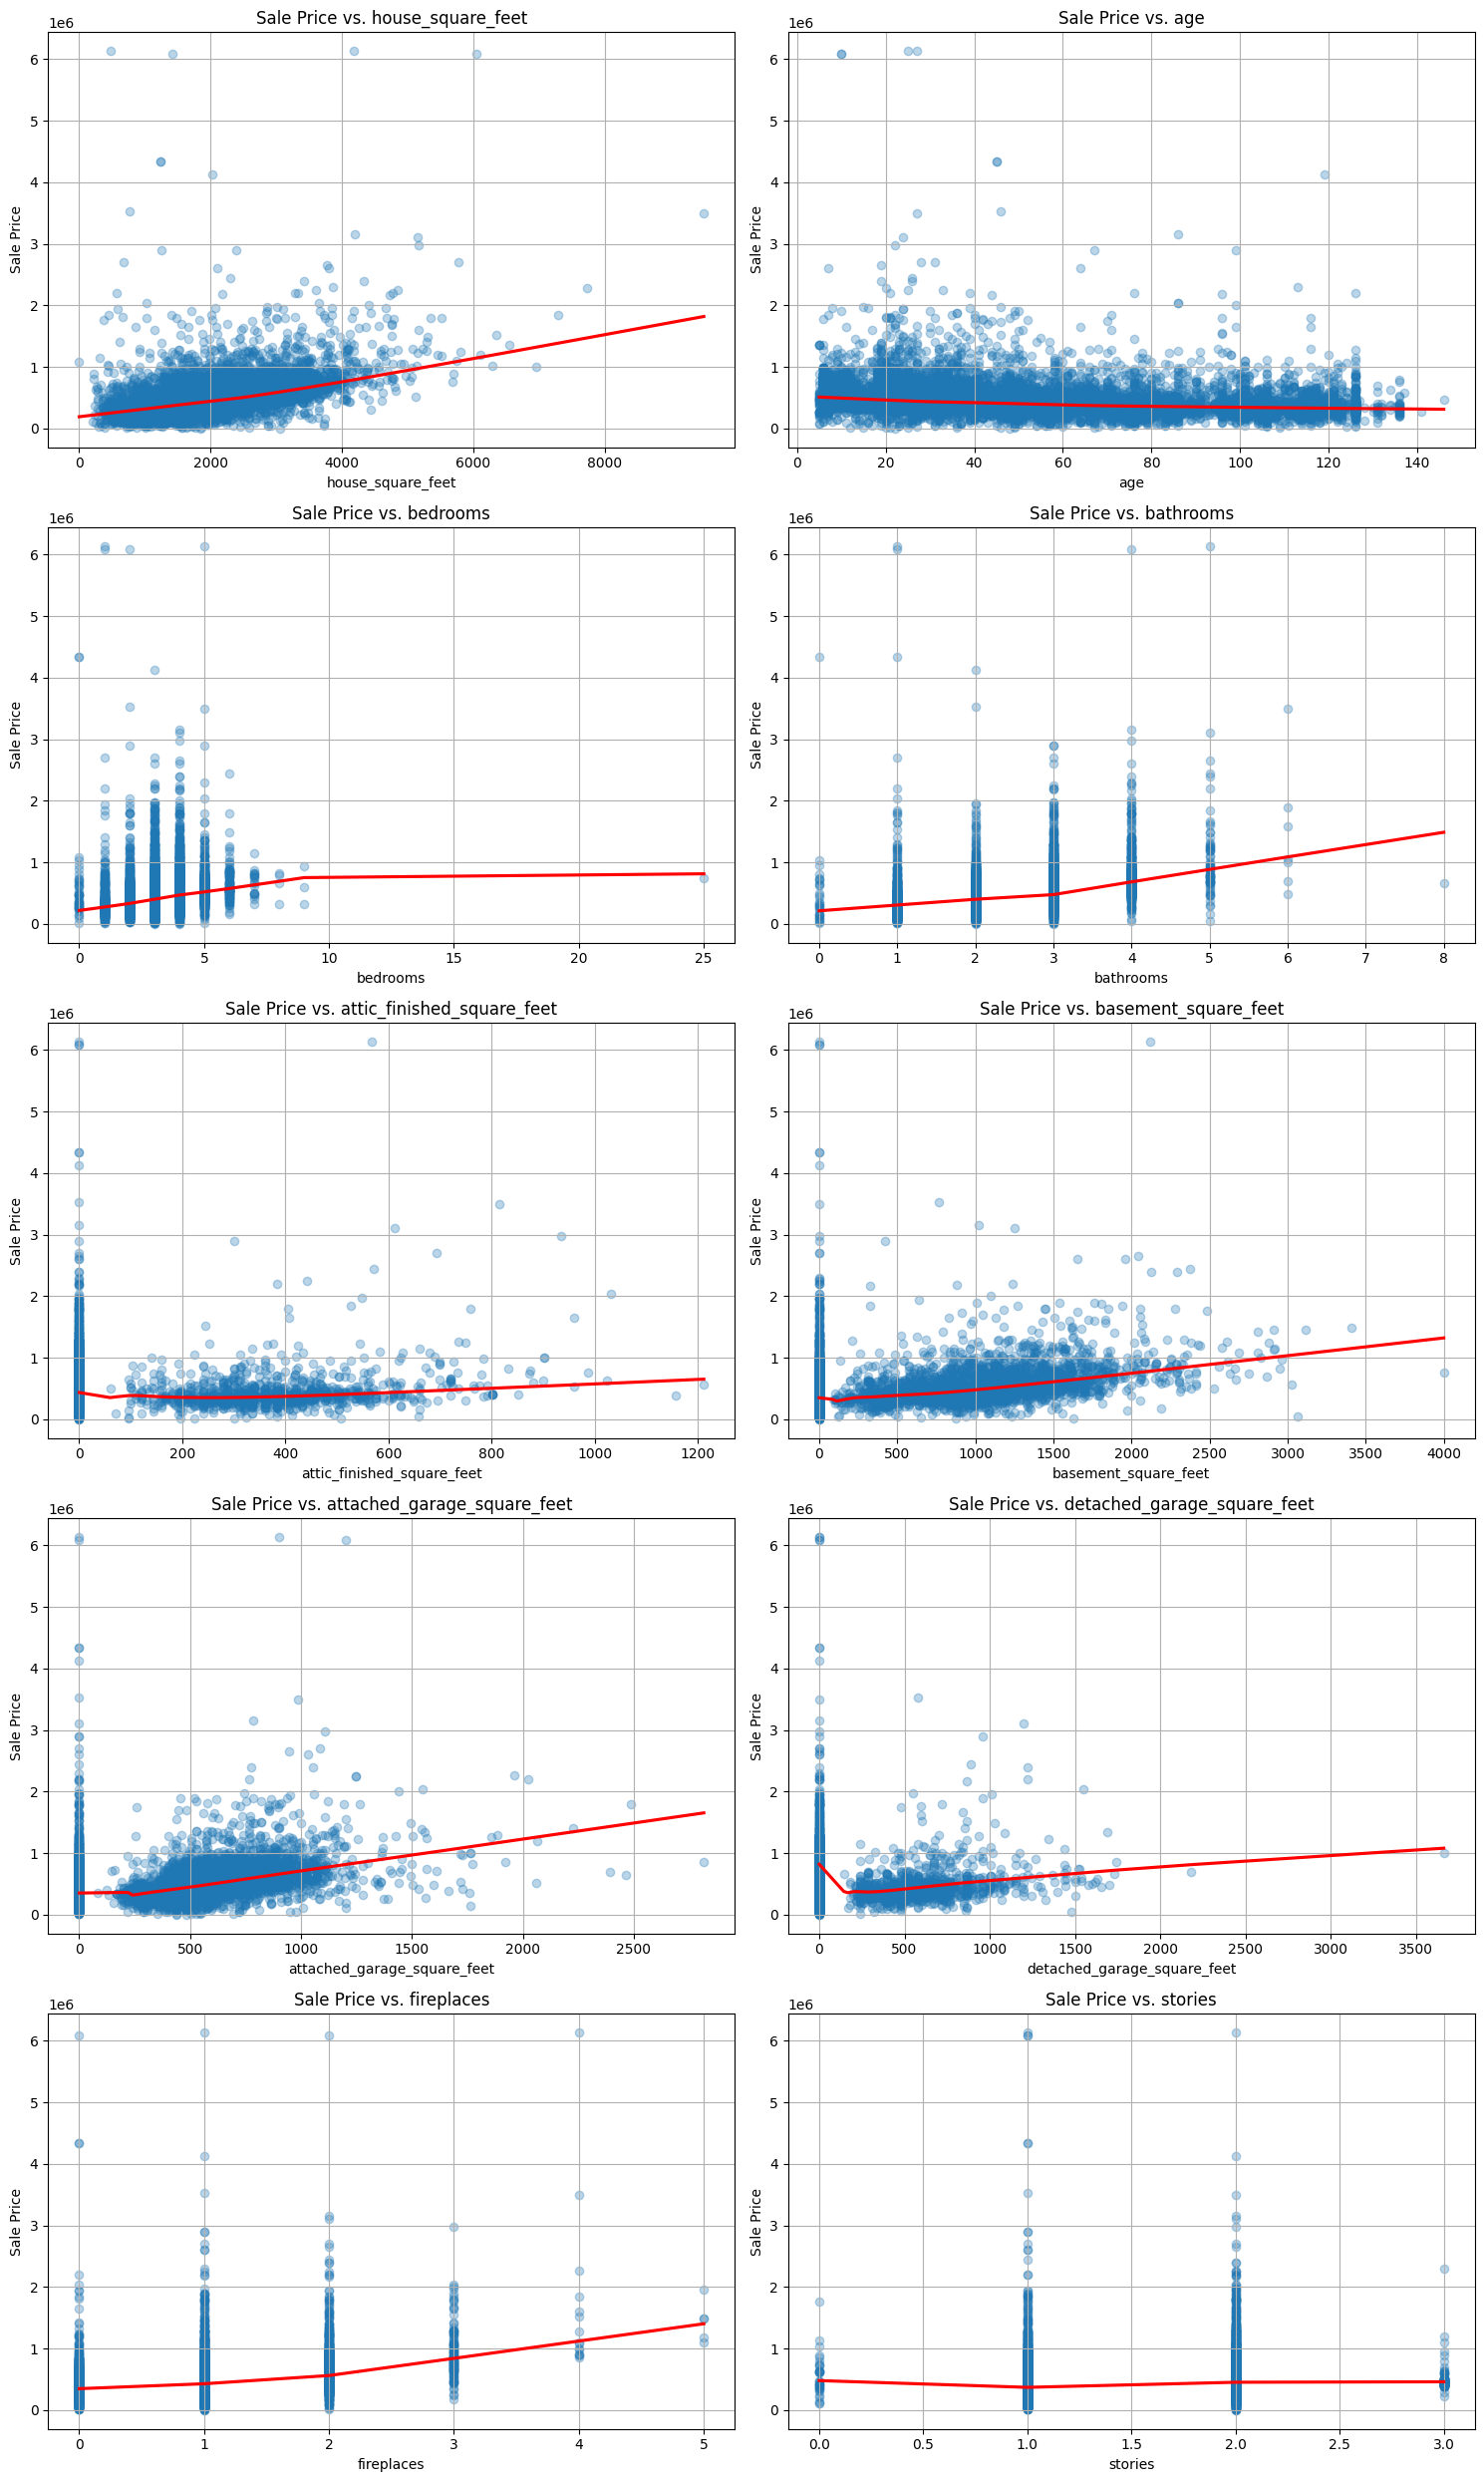

In [20]:
numeric_features = [
    'house_square_feet',
    'age',
    'bedrooms',
    'bathrooms',
    'attic_finished_square_feet',
    'basement_square_feet',
    'attached_garage_square_feet',
    'detached_garage_square_feet',
    'fireplaces',
    'stories'
]

# Create subplots
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 25))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.regplot(x=feature, y='sale_price', data=houses, ax=axes[i], lowess=True,
                scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    axes[i].set_title(f'Sale Price vs. {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Sale Price')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

#generated by GeminiAI

### Model 4: Complex Model with Transformations and Interactions

In [21]:
# Feature Engineering for Model 4
houses_train['total_sq_feet'] = houses_train['house_square_feet'] + houses_train['attic_finished_square_feet'] + \
                                 houses_train['basement_square_feet'] + houses_train['attached_garage_square_feet'] + \
                                 houses_train['detached_garage_square_feet']
houses_test['total_sq_feet'] = houses_test['house_square_feet'] + houses_test['attic_finished_square_feet'] + \
                                houses_test['basement_square_feet'] + houses_test['attached_garage_square_feet'] + \
                                houses_test['detached_garage_square_feet']

# Interaction Term
houses_train['sq_ft_x_bathrooms'] = houses_train['house_square_feet'] * houses_train['bathrooms']
houses_test['sq_ft_x_bathrooms'] = houses_test['house_square_feet'] * houses_test['bathrooms']

model_name = "Model 4: Complex Model"

# Define features (X) and target (y) for the complex model
X_features_4 = [
    'total_sq_feet',
    'age',
    'bedrooms',
    'fireplaces',
    'stories',
    'exterior_encoded',
    'interior_encoded',
    'hvac_description_encoded',
    'sq_ft_x_bathrooms'
]

X_train_4 = houses_train[X_features_4]
y_train_4 = houses_train['sale_price']
X_test_4 = houses_test[X_features_4]
y_test_4 = houses_test['sale_price']

# Initialize and fit the linear regression model
model_4 = LinearRegression()
model_4.fit(X_train_4, y_train_4)

# Make predictions
y_train_pred_4 = model_4.predict(X_train_4)
y_test_pred_4 = model_4.predict(X_test_4)

# Calculate R^2 and RMSE for training set
r2_train_4 = r2_score(y_train_4, y_train_pred_4)
rmse_train_4 = np.sqrt(mean_squared_error(y_train_4, y_train_pred_4))

# Calculate R^2 and RMSE for test set
r2_test_4 = r2_score(y_test_4, y_test_pred_4)
rmse_test_4 = np.sqrt(mean_squared_error(y_test_4, y_test_pred_4))

print(f"--- {model_name} ---")
print(f"Training R^2: {r2_train_4:.4f}")
print(f"Training RMSE: {rmse_train_4:.2f}")
print(f"Test R^2: {r2_test_4:.4f}")
print(f"Test RMSE: {rmse_test_4:.2f}")

print("\n--- Comparison with Simpler Models ---")
print(f"Model 1 (house_square_feet) Test R^2: {r2_test_1:.4f}, Test RMSE: {rmse_test_1:.2f}")
print(f"Model 2 (age) Test R^2: {r2_test_2:.4f}, Test RMSE: {rmse_test_2:.2f}")
print(f"Model 3 (bedrooms, bathrooms) Test R^2: {r2_test_3:.4f}, Test RMSE: {rmse_test_3:.2f}")
print(f"Model 4 (Complex Model) Test R^2: {r2_test_4:.4f}, Test RMSE: {rmse_test_4:.2f}")

#all done by GeminiAI; I told it to use all the features it could to make a comprehensive model that made use of the avaliable numerical variables

--- Model 4: Complex Model ---
Training R^2: 0.4151
Training RMSE: 176338.93
Test R^2: 0.3828
Test RMSE: 201833.52

--- Comparison with Simpler Models ---
Model 1 (house_square_feet) Test R^2: 0.2625, Test RMSE: 220635.05
Model 2 (age) Test R^2: 0.0509, Test RMSE: 250287.14
Model 3 (bedrooms, bathrooms) Test R^2: 0.1545, Test RMSE: 236237.76
Model 4 (Complex Model) Test R^2: 0.3828, Test RMSE: 201833.52


# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?

Sale price using house square feet

Test RMSE: 220635.05

Test $R^2$:0.2625

Training RMSE: 195447.67

Training $R^2$: 0.2814

---
Sale price using age

Test RMSE: 250287.14

Test $R^2$: 0.0509

Training RMSE: 224401.76

Training $R^2$: 0.0528

---

Sale price using bedrooms and bathrooms:

Test RMSE: 236237.76

Test $R^2$: 0.1545

Training RMSE: 209665.39

Training $R^2$: 0.1731

Model 1 performed the best as it had the highest $R^2$ and the lowest RMSE on the test split.


5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?

I don't know if I would describe them as "significant", but a lot of the variables either have a weak or non-linear relationship with sales price. House square feet and age are the most consistently linear. Some of the other variables have non-linear relationships near 0, but then approach linearity over their range. In general, the lack of strong linearity demonstrates a certain degree of limited correlation between certain variables and sales price.

6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?

The more complex model unsuprisingly greatly outperforms the simpler models. This makes sense as it has access to all of the numerical variables and the transformed categorical variables. With more information avaliable, it makes rational sense that it will be better able to predict sales price than a model that only utilizes one or two variables. Additionally, because not all the variables have the same weight/influence when it comes to determining sales price, it outperforms the models that use less relevant variables.

7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?

Models 2 and 3 showed underfitting, probably because there was not a strong influence of the variables on the sales price. This is seen in the low $R^2$ values, which suggests that the underlying pattern/relationship was not being captured and represented by the model.

The more complex Model 4 could be an example of slight overfitting, as the training $R^2$ and the test $R^2$ were similar. This is likely because this model used almost all of the variables avaliable, so there may be a risk where it was seeing "too" much information and instead of capturing a pattern of data, it was just copying the data.

Model selection: I think it just showed that it is important to understand how much influence a variable will have on the output. When selecting the variables for Models 2 and 3, and then looking at the partial correlation plots, it is not a mystery as to why they did not perform as well as Model 1. The variables just were not as influential on sales price as total square footage is. And when making a more complex model that uses multiple variables, it may be unneccessary to use all the variables avaliable. You may be able to get away with using only "significant" variables (something that you would also have to determine).

8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.